# Deliverable 2 — Bipartite Network & Multi-Layer Projection Analysis

Self-contained notebook. Builds the bipartite user–anime graph, constructs
Completed / Dropped / Wishlist co-watch projections, compares their structure,
runs community detection on each layer, and produces the visualization suite.

In [12]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# python-louvain exports community.best_partition; a different 'community' pkg may be installed
try:
    import community as _c
    _ = _c.best_partition   # raises AttributeError if wrong package
except (ImportError, AttributeError):
    print('Installing python-louvain...')
    pip_install('python-louvain')

try:
    import powerlaw
except ImportError:
    print('Installing powerlaw...')
    pip_install('powerlaw')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

print('All packages ready.')

All packages ready.


In [13]:
import warnings
warnings.filterwarnings('ignore')

import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from scipy import sparse, stats
from scipy.sparse import csr_matrix
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations

try:
    import community as community_louvain
    _ = community_louvain.best_partition  # verify it's python-louvain
    HAVE_LOUVAIN = True
except (ImportError, AttributeError):
    HAVE_LOUVAIN = False
    print('python-louvain unavailable — will use NetworkX greedy modularity')

try:
    import powerlaw as pl_lib
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

# --- Auto-detect dataset path (works on Kaggle regardless of dataset slug) ---
_candidates = [
    '/kaggle/input/datasets/shamiksinha/anime-dataset-nsproject',
    '/kaggle/input/anime-dataset-nsproject',
    '/kaggle/input/anime-recommendation-database',
]
DATA_PATH = "Anime_Recommendation_Database"
# for _c in _candidates:
#     if os.path.isfile(os.path.join(_c, 'anime.csv')):
#         DATA_PATH = _c
#         break
# if DATA_PATH is None:
#     _hits = glob.glob('/kaggle/input/**/anime.csv', recursive=True)
#     if _hits:
#         DATA_PATH = os.path.dirname(_hits[0])
# if DATA_PATH is None:
#     raise FileNotFoundError(
#         "Could not find anime.csv under /kaggle/input/.\n"
#         "Make sure the dataset is attached to this notebook. "
#         "Files found under /kaggle/input/: " + str(os.listdir('/kaggle/input/'))
#     )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STATUS_MAP = {1: 'Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}

print('Imports done.')
print(f'NetworkX version: {nx.__version__}')
print(f'Louvain available: {HAVE_LOUVAIN}')
print(f'powerlaw available: {HAVE_POWERLAW}')
print(f'Data path auto-detected: {DATA_PATH}')
print(f'Files: {os.listdir(DATA_PATH)}')

Imports done.
NetworkX version: 3.2.1
Louvain available: True
powerlaw available: True
Data path auto-detected: Anime_Recommendation_Database
Files: ['anime.csv', 'animelist.csv', 'anime_with_synopsis.csv', 'html folder', 'rating_complete.csv', 'watching_status.csv']


## Data Loading & Preprocessing

We load two main files:
- **`anime.csv`** — metadata for each anime (title, genres, type, air date, scores, member counts)
- **`animelist.csv`** — 109M+ user–anime interaction rows (user_id, anime_id, rating, watching_status, watched_episodes)

Because `animelist.csv` is very large, we sample users with `user_id ≤ 9999`. Since the file is sorted by `user_id`, we can stop reading early, giving us ~3M rows covering ~10,000 users — a large, representative sample.

In [14]:
# Load anime metadata
anime_df = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'), low_memory=False)
anime_df.rename(columns={'MAL_ID': 'anime_id'}, inplace=True)

# Parse air year from 'Aired' column
def parse_year(aired_str):
    if pd.isna(aired_str) or aired_str == 'Unknown':
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(aired_str))
    return int(match.group(1)) if match else np.nan

anime_df['air_year'] = anime_df['Aired'].apply(parse_year)

# Convert score to numeric
anime_df['Score'] = pd.to_numeric(anime_df['Score'], errors='coerce')
anime_df['Members'] = pd.to_numeric(anime_df['Members'], errors='coerce')

# Build quick lookup: anime_id -> name, genres
anime_lookup = anime_df.set_index('anime_id')[['Name','Genres','Type','air_year','Score','Members']]

print(f'Anime metadata loaded: {anime_df.shape[0]} anime titles')
print(f'Year range (non-null): {int(anime_df["air_year"].min())} – {int(anime_df["air_year"].max())}')
print(f'Genres sample: {anime_df["Genres"].dropna().iloc[0]}')
anime_df[['anime_id','Name','Score','Genres','Type','air_year','Members']].head(5)

Anime metadata loaded: 17562 anime titles
Year range (non-null): 1917 – 2022
Genres sample: Action, Adventure, Comedy, Drama, Sci-Fi, Space


,anime_id,Name,Score,Genres,Type,air_year,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,1998.0,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Movie,2001.0,273145
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",TV,1998.0,558913
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",TV,2002.0,94683
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",TV,2004.0,13224


In [15]:
# Load animelist — two sampling strategies available:
#
#   FAST (default):  users 0–9,999 → ~3M rows, loads in ~10s
#                    Bias: early MAL users, skews toward older anime & power users
#
#   REPRESENTATIVE:  modulo-hash sample (every 30th user_id across full file) → ~3.6M rows
#                    reads all 109M rows (~3-5 min on Kaggle), but spreads evenly over all users
#
# Set REPRESENTATIVE_SAMPLE = True to use the slower but unbiased version.

REPRESENTATIVE_SAMPLE = True   # flip to True for unbiased sampling

CHUNK = 500_000
chunks = []

if not REPRESENTATIVE_SAMPLE:
    SAMPLE_MAX_UID = 9999
    print(f'Loading animelist (fast mode: users 0–{SAMPLE_MAX_UID})...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] <= SAMPLE_MAX_UID]
        chunks.append(sub)
        if chunk['user_id'].max() > SAMPLE_MAX_UID:
            break
else:
    MODULO = 10   # keep every 30th user_id → ~1/30 of all users, spread across full range
    print(f'Loading animelist (representative mode: user_id % {MODULO} == 0, reads full file)...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] % MODULO == 0]
        chunks.append(sub)

animelist = pd.concat(chunks, ignore_index=True)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Shape: {animelist.shape}')
print(f'Unique users:  {animelist["user_id"].nunique():,}')
print(f'Unique anime:  {animelist["anime_id"].nunique():,}')

print('\nWatching status breakdown:')
status_counts = animelist['watching_status'].map(STATUS_MAP).value_counts()
for status, count in status_counts.items():
    print(f'  {status:<18}: {count:>9,} rows ({100*count/len(animelist):.1f}%)')

Loading animelist (representative mode: user_id % 10 == 0, reads full file)...
Loaded in 25.6s
Shape: (11002813, 5)
Unique users:  32,575
Unique anime:  17,551

Watching status breakdown:
  Completed         : 6,860,393 rows (62.4%)
  Plan to Watch     : 2,791,683 rows (25.4%)
  Watching          :   518,253 rows (4.7%)
  Dropped           :   453,575 rows (4.1%)
  On Hold           :   378,892 rows (3.4%)


## Working DataFrames — Column Reference

After loading, we work with two core DataFrames throughout the notebook:

---

### `anime_df` — Anime Metadata Table
Shape: ~17,562 rows × 36 columns. Each row is one anime title.

| Column | Type | Description |
|--------|------|-------------|
| `anime_id` | int | Unique anime ID (renamed from `MAL_ID`). Primary key — used to join with `animelist`. |
| `Name` | str | Canonical romanized title |
| `Score` | float | Weighted average community rating (1–10). `NaN` if not enough votes. |
| `Genres` | str | Comma-separated genre tags, e.g. `"Action, Adventure, Comedy"`. We split on `,` to get individual genres. |
| `Type` | str | Format of the release: `TV`, `Movie`, `OVA`, `ONA`, `Special`, `Music` |
| `Episodes` | str | Episode count (`"Unknown"` for ongoing/unknown) |
| `Aired` | str | Raw air date string, e.g. `"Apr 3, 1998 to Apr 24, 1999"`. We parse the first 4-digit year from this → `air_year`. |
| `Members` | int | Total number of MAL users who have this title in any list — proxy for popularity |
| `Completed` | int | Aggregate count of users who marked it completed |
| `Dropped` | int | Aggregate count of users who dropped it |
| `Watching` | int | Aggregate count currently watching |
| `Plan to Watch` | int | Aggregate count planning to watch |
| `Favorites` | int | Number of users who marked it as a favourite |
| `Score-1` … `Score-10` | float | Distribution of individual ratings (how many users gave each score) |
| `air_year` *(derived)* | float | Parsed 4-digit start year from `Aired`. Used in Deliverable 5 for temporal snapshots. |

---

### `animelist` — User Interaction Log (sampled)
Shape: ~3M rows × 5 columns. Each row is one user's record for one anime.

| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Anonymous user identifier. We sample users `0–9999` to keep the dataset tractable. |
| `anime_id` | int | Links to `anime_df`. The anime this row refers to. |
| `rating` | int | User's personal rating (1–10). `0` means the user didn't leave a rating. |
| `watching_status` | int | Current engagement status: `1` Watching · `2` **Completed** · `3` On Hold · `4` **Dropped** · `6` **Plan to Watch** |
| `watched_episodes` | int | Number of episodes the user has watched so far |

> **How these two tables connect:** `animelist.anime_id` → `anime_df.anime_id`. The `animelist` table tells us *who* watched *what* and *how*, while `anime_df` tells us the properties of each title. Most of the network construction work happens on `animelist`, and `anime_df` provides node attributes (genre, score, year, etc.).

---
## Deliverable 2 — Bipartite Network & Multi-Layer Projection Analysis

We build the explicit **bipartite user–anime graph** with users on one side and anime on the other. We then construct **three separate anime-layer projections** based on different engagement types:

| Layer | Status Code | Behavior |
|-------|------------|----------|
| **Completed** | 2 | User watched through to the end |
| **Dropped** | 4 | User started but abandoned |
| **Wishlist** | 6 | User plans to watch |

We compare the edge sets across projections using Jaccard similarity, and analyze structural differences to understand whether anime co-watch similarity changes depending on how users engage.

In [16]:
# Build bipartite user-anime graph
# Sample up to MAX_BIPARTITE_USERS from whoever is actually in animelist
# (works correctly regardless of whether fast or representative sampling was used)
from networkx.algorithms import bipartite

MAX_BIPARTITE_USERS = 10000

all_users = animelist['user_id'].unique()
if len(all_users) > MAX_BIPARTITE_USERS:
    rng_bip = np.random.default_rng(RANDOM_SEED)
    chosen_users = rng_bip.choice(all_users, MAX_BIPARTITE_USERS, replace=False)
else:
    chosen_users = all_users

bip_data = animelist[animelist['user_id'].isin(chosen_users)]

# Restrict to top 1500 anime for efficiency
TOP_BIP = 3000
bip_top_anime = bip_data['anime_id'].value_counts().head(TOP_BIP).index
bip_data = bip_data[bip_data['anime_id'].isin(bip_top_anime)]

# Build bipartite graph
B = nx.Graph()
user_nodes  = [f'u_{uid}' for uid in bip_data['user_id'].unique()]
anime_nodes = [f'a_{aid}' for aid in bip_data['anime_id'].unique()]

B.add_nodes_from(user_nodes,  bipartite=0)
B.add_nodes_from(anime_nodes, bipartite=1)

edges = [(f'u_{row.user_id}', f'a_{row.anime_id}') for row in bip_data.itertuples()]
B.add_edges_from(edges)

# Also update bip_base used later for projections
bip_base = bip_data.copy()

print(f'Bipartite graph built:')
print(f'  User nodes:   {len(user_nodes):,} ')
print(f'  Anime nodes:  {len(anime_nodes):,}')
print(f'  Edges:        {B.number_of_edges():,}')
print(f'  Is bipartite: {bipartite.is_bipartite(B)}')
print()
print(f"Number of connected components: {nx.number_connected_components(B)}")

Bipartite graph built:
  User nodes:   9,987 
  Anime nodes:  3,000
  Edges:        2,859,083
  Is bipartite: True

Number of connected components: 1


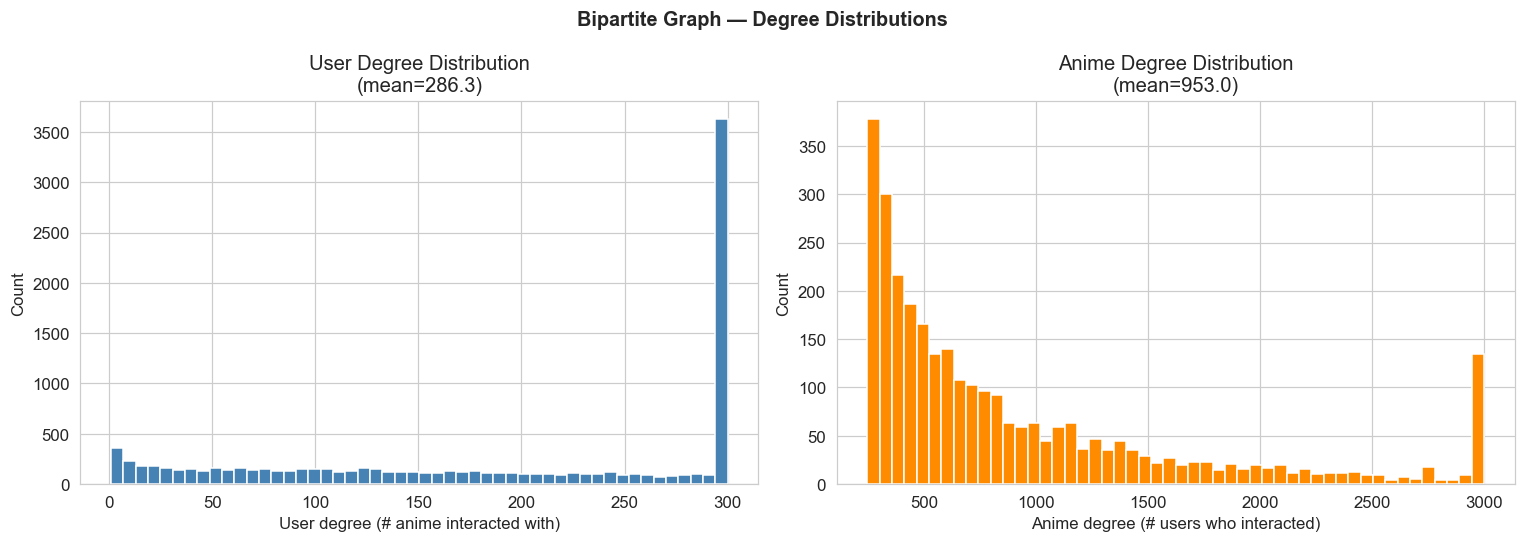

In [17]:
# Bipartite degree distributions
user_set  = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 0}
anime_set = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 1}

user_degrees  = [B.degree(n) for n in user_set]
anime_degrees = [B.degree(n) for n in anime_set]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.clip(user_degrees, 0, 300), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('User degree (# anime interacted with)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'User Degree Distribution\n(mean={np.mean(user_degrees):.1f})')

axes[1].hist(np.clip(anime_degrees, 0, 3000), bins=50, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Anime degree (# users who interacted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Anime Degree Distribution\n(mean={np.mean(anime_degrees):.1f})')

plt.suptitle('Bipartite Graph — Degree Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_bipartite_degrees.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Build three separate anime-layer projections — true projections of bipartite graph B
#
# A projection means: take the edges already in B, filter by status,
# then connect two anime nodes if they share at least min_cowatch common user neighbours.
# We restrict to EXACTLY the user and anime nodes that are in B — nothing else.

# Extract node sets directly from B
users_in_B = {int(n.split('_')[1]) for n in user_set}
anime_in_B = {int(n.split('_')[1]) for n in anime_set}
print(f'Nodes in B  →  users: {len(users_in_B):,}   anime: {len(anime_in_B):,}')

# Per-layer thresholds
THRESH = {2: 600, 4: 6, 6: 100}    # Completed: 5  |  Dropped / Wishlist: 2

def build_projection(df_filtered, min_cowatch=5):
    """Anime-layer projection using only nodes already in B.
    Two anime are connected if ≥ min_cowatch users (who are in B) share both.
    """
    df = df_filtered[
        df_filtered['user_id'].isin(users_in_B) &
        df_filtered['anime_id'].isin(anime_in_B)
    ].copy()
    if len(df) == 0:
        return nx.Graph()
    u_e = LabelEncoder(); a_e = LabelEncoder()
    u_i = u_e.fit_transform(df['user_id'])
    a_i = a_e.fit_transform(df['anime_id'])
    M = csr_matrix((np.ones(len(u_i)), (u_i, a_i)),
                   shape=(len(u_e.classes_), len(a_e.classes_)))
    C = (M.T @ M).toarray().astype(int)
    np.fill_diagonal(C, 0)
    rs, cs = np.where(np.triu(C, k=1) >= min_cowatch)
    Gp = nx.Graph()
    Gp.add_nodes_from(a_e.classes_)
    for r, c in zip(rs, cs):
        Gp.add_edge(int(a_e.classes_[r]), int(a_e.classes_[c]), weight=int(C[r, c]))
    return Gp

# Diagnostic: interactions per status restricted to nodes in B
print('\nInteractions per status (users & anime both restricted to nodes in B):')
bip_restricted = bip_base[
    bip_base['user_id'].isin(users_in_B) &
    bip_base['anime_id'].isin(anime_in_B)
]
for code, label in STATUS_MAP.items():
    sub = bip_restricted[bip_restricted['watching_status'] == code]
    print(f'  {label:<18}: {len(sub):>8,} rows  ({sub["user_id"].nunique():>5,} users)')

print()
G_comp = build_projection(bip_base[bip_base['watching_status'] == 2], THRESH[2])
G_drop = build_projection(bip_base[bip_base['watching_status'] == 4], THRESH[4])
G_wish = build_projection(bip_base[bip_base['watching_status'] == 6], THRESH[6])

layer_names  = ['Completed', 'Dropped', 'Wishlist']
layer_graphs = [G_comp, G_drop, G_wish]
layer_thresh = [THRESH[2], THRESH[4], THRESH[6]]

print(f'{"Layer":<12} {"Threshold":>10} {"Nodes":>8} {"Edges":>10} {"Density":>10} {"Avg Degree":>12} {"Avg Clustering":>16}')
print('-' * 80)
for name, Gp, thr in zip(layer_names, layer_graphs, layer_thresh):
    if Gp.number_of_nodes() == 0:
        print(f'{name:<12} {thr:>10}  No data')
        continue
    ad = np.mean([d for _, d in Gp.degree()])
    ac = nx.average_clustering(Gp) if Gp.number_of_edges() > 0 else 0
    print(f'{name:<12} {thr:>10} {Gp.number_of_nodes():>8,} {Gp.number_of_edges():>10,} '
          f'{nx.density(Gp):>10.5f} {ad:>12.2f} {ac:>16.4f}')

Nodes in B  →  users: 9,987   anime: 3,000

Interactions per status (users & anime both restricted to nodes in B):
  Watching          :  139,956 rows  (9,266 users)
  Completed         : 1,831,411 rows  (9,832 users)
  On Hold           :   98,130 rows  (6,891 users)
  Dropped           :  113,031 rows  (6,928 users)
  Plan to Watch     :  676,545 rows  (8,949 users)

Layer         Threshold    Nodes      Edges    Density   Avg Degree   Avg Clustering
--------------------------------------------------------------------------------
Completed           600    2,940     45,578    0.01055        31.01           0.2349
Dropped               6    2,919    197,555    0.04639       135.36           0.4113
Wishlist            100    3,000     62,892    0.01398        41.93           0.2727


=== Pairwise Jaccard Similarity of Edge Sets ===
  Completed  ∩ Dropped   / Completed  ∪ Dropped:   J = 0.0616
  Completed  ∩ Wishlist  / Completed  ∪ Wishlist:  J = 0.1628
  Dropped    ∩ Wishlist  / Dropped    ∪ Wishlist:  J = 0.0989


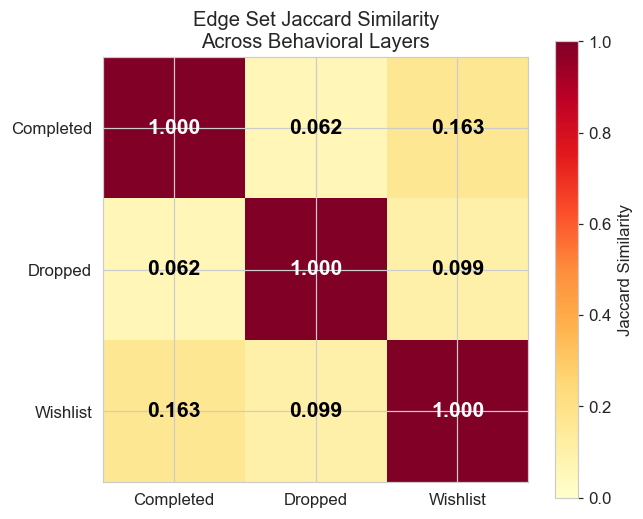

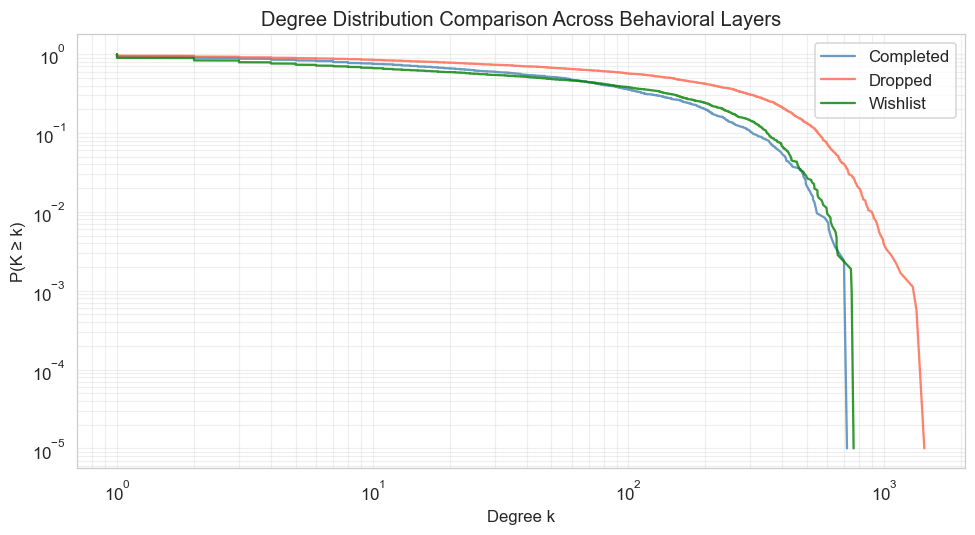

In [19]:
# Edge set similarity between the three projections (Jaccard index)
def edge_set(Gp):
    return {(min(u,v), max(u,v)) for u, v in Gp.edges()}

e_comp = edge_set(G_comp)
e_drop = edge_set(G_drop)
e_wish = edge_set(G_wish)

def jaccard(A, B):
    if not A and not B:
        return 1.0
    inter = len(A & B)
    union = len(A | B)
    return inter / union if union > 0 else 0.0

j_cd = jaccard(e_comp, e_drop)
j_cw = jaccard(e_comp, e_wish)
j_dw = jaccard(e_drop, e_wish)

print('=== Pairwise Jaccard Similarity of Edge Sets ===')
print(f'  Completed  ∩ Dropped   / Completed  ∪ Dropped:   J = {j_cd:.4f}')
print(f'  Completed  ∩ Wishlist  / Completed  ∪ Wishlist:  J = {j_cw:.4f}')
print(f'  Dropped    ∩ Wishlist  / Dropped    ∪ Wishlist:  J = {j_dw:.4f}')

# Visualize as a heatmap
sim_matrix = np.array([[1.0, j_cd, j_cw],
                        [j_cd, 1.0, j_dw],
                        [j_cw, j_dw, 1.0]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Jaccard Similarity')
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(layer_names); ax.set_yticklabels(layer_names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if sim_matrix[i,j] > 0.5 else 'black')
ax.set_title('Edge Set Jaccard Similarity\nAcross Behavioral Layers')
plt.tight_layout()
plt.savefig('d2_edge_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Degree distribution comparison across layers
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'tomato', 'green']
for name, Gp, col in zip(layer_names, layer_graphs, colors):
    if Gp.number_of_nodes() > 0:
        degs = sorted([d for _, d in Gp.degree() if d > 0])
        ccdf = 1 - np.arange(1, len(degs)+1)/len(degs)
        ax.loglog(degs, ccdf + 1e-5, '-', color=col, label=name, alpha=0.8)
ax.set_xlabel('Degree k')
ax.set_ylabel('P(K ≥ k)')
ax.set_title('Degree Distribution Comparison Across Behavioral Layers')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('d2_layer_degree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

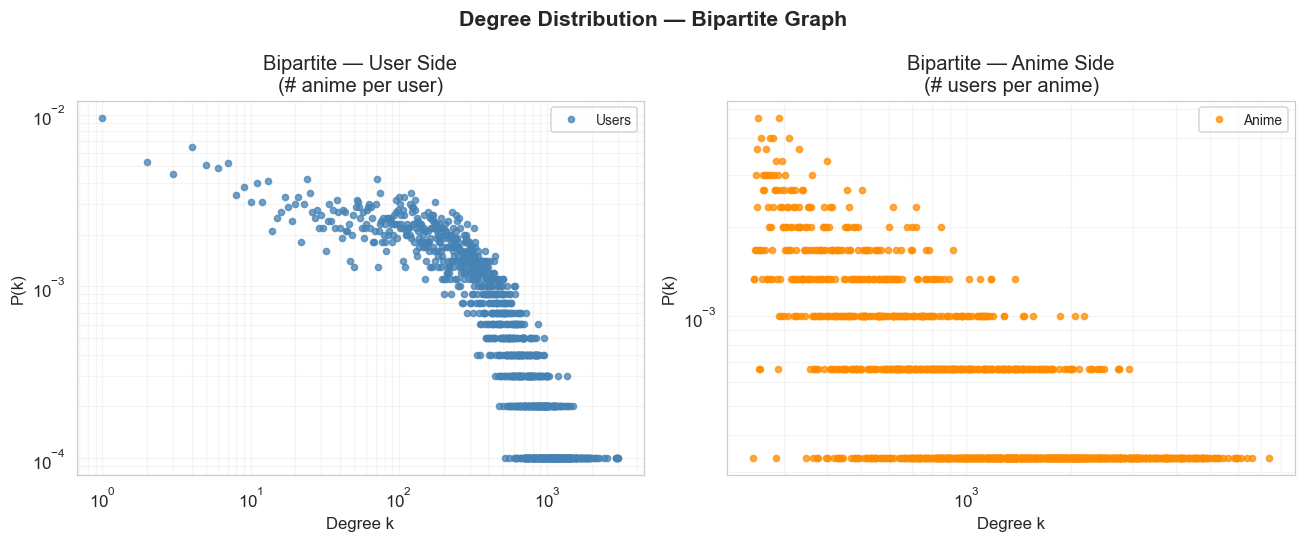

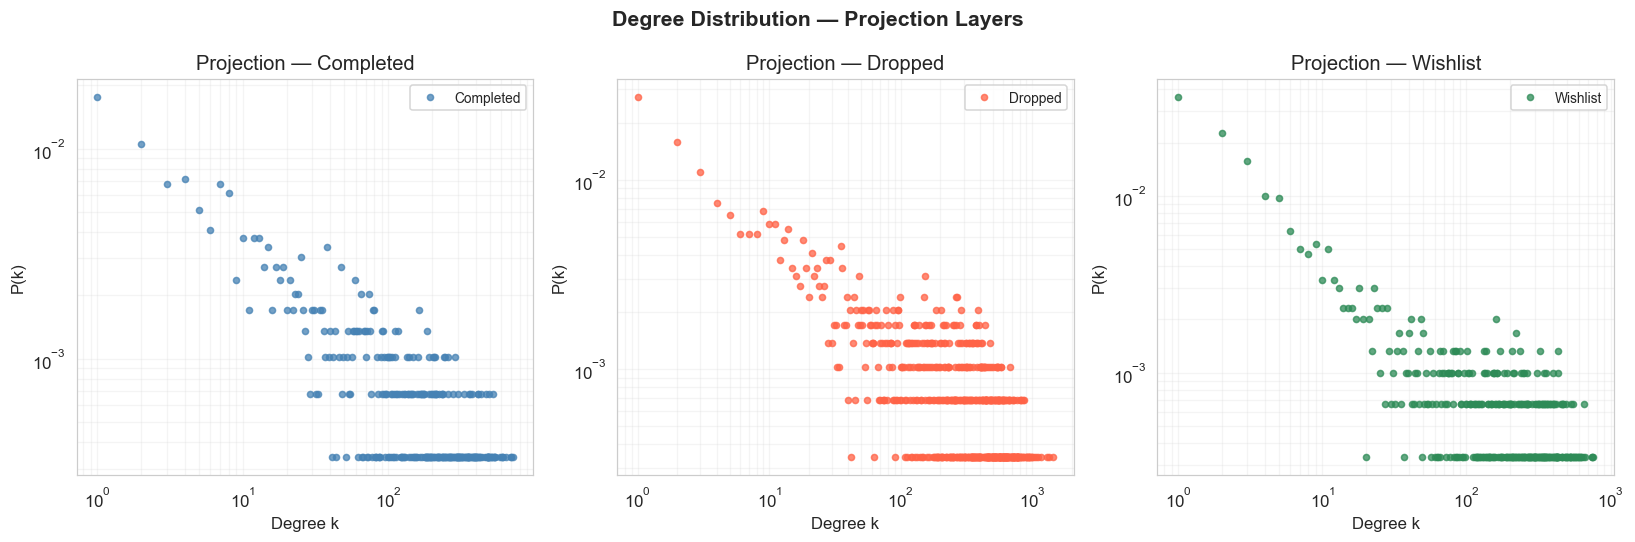

Layer                    Nodes   Min k   Max k   Mean k   Median k
-----------------------------------------------------------------
Bipartite Users          9,987       1    3000    286.3        208
Bipartite Anime          3,000     245    7383    953.0        624
Projection Completed     2,940       0     716     31.0          0
Projection Dropped       2,919       0    1437    135.4         15
Projection Wishlist      3,000       0     760     41.9          0


In [20]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Clean P(k) plot (NO fit, NO R², NO kmin)
# ─────────────────────────────────────────────
def pk_loglog(ax, degrees, label, color):
    if not degrees:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return

    counter = Counter(degrees)
    k_vals  = np.array(sorted(counter.keys()))
    pk_vals = np.array([counter[k] / len(degrees) for k in k_vals])

    mask = k_vals > 0
    k_vals, pk_vals = k_vals[mask], pk_vals[mask]

    ax.loglog(k_vals, pk_vals, 'o',
              color=color, alpha=0.75, markersize=4, label=label)

    ax.grid(True, which='both', alpha=0.2)
    ax.set_xlabel('Degree k')
    ax.set_ylabel('P(k)')
    ax.legend(fontsize=9)


# =========================================================
# 🔵 FIGURE 1 — Bipartite (User + Anime together)
# =========================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

# User side
u_degs = [B.degree(n) for n in user_set]
pk_loglog(axes1[0], u_degs, 'Users', 'steelblue')
axes1[0].set_title('Bipartite — User Side\n(# anime per user)')

# Anime side
a_degs = [B.degree(n) for n in anime_set]
pk_loglog(axes1[1], a_degs, 'Anime', 'darkorange')
axes1[1].set_title('Bipartite — Anime Side\n(# users per anime)')

fig1.suptitle('Degree Distribution — Bipartite Graph',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('d2_pk_bipartite.png', dpi=150, bbox_inches='tight')
plt.show()


# =========================================================
# 🟢 FIGURE 2 — Projection Layers (3 together)
# =========================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

proj_data = [
    (G_comp, 'Completed', 'steelblue'),
    (G_drop, 'Dropped',   'tomato'),
    (G_wish, 'Wishlist',  'seagreen'),
]

for ax, (Gp, name, col) in zip(axes2, proj_data):
    if Gp.number_of_nodes() > 0:
        degs = [d for _, d in Gp.degree()]
        pk_loglog(ax, degs, name, col)

    ax.set_title(f'Projection — {name}')

fig2.suptitle('Degree Distribution — Projection Layers',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('d2_pk_projections.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f'{"Layer":<22} {"Nodes":>7} {"Min k":>7} {"Max k":>7} {"Mean k":>8} {"Median k":>10}')
print('-' * 65)

for label, degs in [
    ('Bipartite Users',  [B.degree(n) for n in user_set]),
    ('Bipartite Anime',  [B.degree(n) for n in anime_set]),
    ('Projection Completed', [d for _,d in G_comp.degree()]),
    ('Projection Dropped',   [d for _,d in G_drop.degree()]),
    ('Projection Wishlist',  [d for _,d in G_wish.degree()]),
]:
    if degs:
        print(f'{label:<22} {len(degs):>7,} {min(degs):>7} {max(degs):>7} '
              f'{np.mean(degs):>8.1f} {np.median(degs):>10.0f}')

### Interpreting the Bipartite & Projection Degree Distributions

**Bipartite — User side:** Each user node's degree is the number of anime they interacted with. A heavy right tail here means a small number of power users dominate the graph — most users have moderate lists.

**Bipartite — Anime side:** Each anime node's degree is the number of users who interacted with it. A very steep drop-off confirms the popularity inequality seen in the EDA: most anime are niche, a handful are mainstream hubs.

**Projections (Completed / Dropped / Wishlist):** Each node is an anime; degree = number of other anime it co-occurs with in that behavioral layer. Comparing the three:
- **Completed** should have the densest, most heavy-tailed distribution — completions reflect genuine sustained interest, so popular anime co-occur with many others
- **Dropped** tends to be sparser — users drop anime for varied reasons, leading to less consistent co-drop patterns
- **Wishlist** is often the flattest — aspirational lists are broad and noisy, so co-occurrence is more uniform

If all three follow a similar power-law slope γ, the underlying taste structure is stable across behaviors. If γ differs across layers, each behavior captures a distinct dimension of anime affinity.

  Community Detection on Projection Layers

Completed:
  Communities : 5
  Modularity  : 0.1363
  Largest 5   : [409, 249, 170, 3, 2]

Dropped:
  Communities : 5
  Modularity  : 0.2280
  Largest 5   : [750, 441, 336, 265, 3]

Wishlist:
  Communities : 8
  Modularity  : 0.1470
  Largest 5   : [334, 273, 208, 208, 8]

  Taste Profiles — Top 5 Communities per Layer

--- Completed ---
  Community 1 (n=409)
    Genres : Comedy, Action, Drama, Romance, Supernatural
    Titles : Cowboy Bebop, Acchi Kocchi (TV), Cowboy Bebop: Tengoku no Tobira, Trigun, Tengen Toppa Gurren Lagann Movie 1: Gurren-hen
  Community 2 (n=249)
    Genres : Action, Comedy, Fantasy, Shounen, Supernatural
    Titles : Kiseijuu: Sei no Kakuritsu, Tsuki ga Kirei, Saenai Heroine no Sodatekata ♭, Arifureta Shokugyou de Sekai Saikyou, Noragami
  Community 3 (n=170)
    Genres : Comedy, Romance, School, Harem, Ecchi
    Titles : Kyoukai no Kanata Movie 2: I'll Be Here - Mirai-hen, Campione!: Matsurowanu Kamigami to Kamigorosh

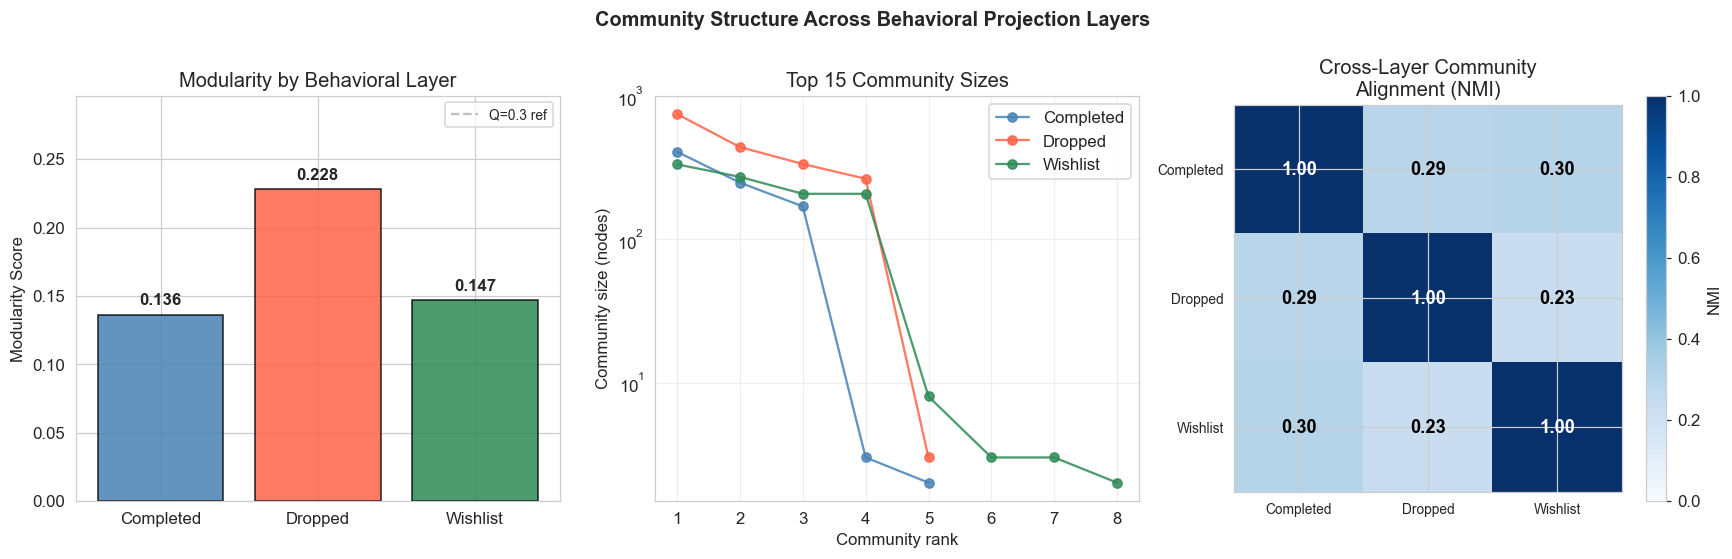

In [21]:
# === Community Detection on the Three Projection Layers (Deliverable 2 Extension) ===
#
# We run Louvain (greedy-modularity fallback) on the GCC of each projection,
# extract the top-5 taste communities, compute cross-layer alignment via NMI,
# and identify bridge anime with high betweenness centrality.

from collections import defaultdict
try:
    from sklearn.metrics import normalized_mutual_info_score
    HAVE_SKL = True
except ImportError:
    HAVE_SKL = False

# ── Lookup tables ──────────────────────────────────────────────────────────────
id_to_title  = anime_df.set_index('anime_id')['Name'].to_dict()
id_to_genres = anime_df.set_index('anime_id')['Genres'].fillna('').to_dict()

# ── Community detection helper ─────────────────────────────────────────────────
def detect_communities_proj(Gp, name):
    if Gp.number_of_nodes() == 0 or Gp.number_of_edges() == 0:
        print(f'  {name}: no edges — skipping')
        return {}, float('nan')
    gcc_nodes = max(nx.connected_components(Gp), key=len)
    Gp_gcc    = Gp.subgraph(gcc_nodes).copy()
    if HAVE_LOUVAIN:
        try:
            part = community_louvain.best_partition(Gp_gcc, random_state=RANDOM_SEED)
            mod  = community_louvain.modularity(part, Gp_gcc)
            return part, mod
        except Exception:
            pass
    from networkx.algorithms.community import greedy_modularity_communities, modularity as nx_mod
    comms = list(greedy_modularity_communities(Gp_gcc))
    part  = {n: i for i, comm in enumerate(comms) for n in comm}
    mod   = nx_mod(Gp_gcc, comms)
    return part, mod

# ── Run detection on all three layers ─────────────────────────────────────────
print('=' * 65)
print('  Community Detection on Projection Layers')
print('=' * 65)
layer_partitions   = {}
layer_modularities = {}
layer_comm_sizes   = {}

for name, Gp in zip(layer_names, layer_graphs):
    part, mod = detect_communities_proj(Gp, name)
    layer_partitions[name]   = part
    layer_modularities[name] = mod
    if part:
        sizes = Counter(part.values())
        layer_comm_sizes[name] = sorted(sizes.values(), reverse=True)
        print(f'\n{name}:')
        print(f'  Communities : {len(sizes)}')
        print(f'  Modularity  : {mod:.4f}')
        print(f'  Largest 5   : {layer_comm_sizes[name][:5]}')

# ── Taste profiles for top-5 communities ──────────────────────────────────────
print('\n' + '=' * 65)
print('  Taste Profiles — Top 5 Communities per Layer')
print('=' * 65)

def print_taste_profiles(part, name, top_n=5, top_k=5):
    if not part:
        return
    comm_members = defaultdict(list)
    for node, cid in part.items():
        comm_members[cid].append(node)
    sorted_comms = sorted(comm_members.items(), key=lambda x: -len(x[1]))[:top_n]
    print(f'\n--- {name} ---')
    for rank, (cid, members) in enumerate(sorted_comms, 1):
        genre_ctr = Counter()
        for m in members:
            for g in id_to_genres.get(m, '').split(','):
                g = g.strip()
                if g:
                    genre_ctr[g] += 1
        top_genres = [g for g, _ in genre_ctr.most_common(5)]
        top_titles = [id_to_title.get(m, f'ID:{m}') for m in members[:top_k]]
        print(f'  Community {rank} (n={len(members):,})')
        print(f"    Genres : {', '.join(top_genres) if top_genres else 'N/A'}")
        print(f"    Titles : {', '.join(top_titles)}")

for name in layer_names:
    print_taste_profiles(layer_partitions[name], name)

# ── Cross-layer community alignment (NMI) ─────────────────────────────────────
print('\n' + '=' * 65)
print('  Cross-Layer Community Alignment (NMI)')
print('=' * 65)

layer_pairs = [('Completed', 'Dropped'), ('Completed', 'Wishlist'), ('Dropped', 'Wishlist')]
nmi_results = {}
for l1, l2 in layer_pairs:
    p1, p2 = layer_partitions.get(l1, {}), layer_partitions.get(l2, {})
    common  = sorted(set(p1.keys()) & set(p2.keys()))
    if len(common) < 10:
        print(f'  NMI({l1:<10} , {l2:<10}) : not enough shared nodes ({len(common)})')
        continue
    if HAVE_SKL:
        labels1 = [p1[n] for n in common]
        labels2 = [p2[n] for n in common]
        nmi = normalized_mutual_info_score(labels1, labels2)
        nmi_results[(l1, l2)] = nmi
        print(f'  NMI({l1:<10} , {l2:<10}) : {nmi:.4f}   (shared nodes: {len(common):,})')
    else:
        print('  sklearn not available — skipping NMI')

# ── Bridge nodes (high betweenness, cross-community) ──────────────────────────
print('\n' + '=' * 65)
print('  Bridge Nodes — High Betweenness Centrality')
print('=' * 65)

for name, Gp in zip(layer_names, layer_graphs):
    if Gp.number_of_edges() == 0:
        continue
    part = layer_partitions.get(name, {})
    if not part:
        continue
    gcc_nodes = max(nx.connected_components(Gp), key=len)
    Gp_gcc    = Gp.subgraph(gcc_nodes).copy()
    k_samp    = min(300, Gp_gcc.number_of_nodes())
    bc = nx.betweenness_centrality(Gp_gcc, k=k_samp, normalized=True, seed=RANDOM_SEED)
    top_bc = sorted(bc.items(), key=lambda x: -x[1])[:8]
    print(f'\n{name} — Top Bridge Nodes:')
    print(f'  {"Title":<40} {"BC":>7} {"Cross-comm nbrs":>17} {"Deg":>5}')
    print('  ' + '-' * 72)
    for node, bval in top_bc:
        title = id_to_title.get(node, f'ID:{node}')[:40]
        nbrs  = list(Gp_gcc.neighbors(node))
        cross = sum(1 for nb in nbrs if part.get(nb, part.get(node)) != part.get(node))
        deg   = len(nbrs)
        print(f'  {title:<40} {bval:>7.4f} {cross:>17} {deg:>5}')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['steelblue', 'tomato', 'seagreen']

# 1. Modularity comparison bar chart
valid_mods = {k: v for k, v in layer_modularities.items() if not np.isnan(v)}
ax = axes[0]
ax.bar(list(valid_mods.keys()), list(valid_mods.values()),
       color=[colors_bar[layer_names.index(k)] for k in valid_mods], alpha=0.85, edgecolor='black')
ax.set_ylabel('Modularity Score')
ax.set_title('Modularity by Behavioral Layer')
ax.set_ylim(0, max(valid_mods.values()) * 1.3 if valid_mods else 1)
for i, (k, v) in enumerate(valid_mods.items()):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='Q=0.3 ref')
ax.legend(fontsize=9)

# 2. Community size distribution (top 15) — log scale
ax = axes[1]
for name, col in zip(layer_names, colors_bar):
    sizes = layer_comm_sizes.get(name, [])
    if sizes:
        x = range(1, min(16, len(sizes)+1))
        ax.plot(x, sizes[:15], 'o-', color=col, label=name, alpha=0.85)
ax.set_xlabel('Community rank')
ax.set_ylabel('Community size (nodes)')
ax.set_title('Top 15 Community Sizes')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Cross-layer NMI heatmap
ax = axes[2]
nmi_mat = np.eye(3)
idx = {n: i for i, n in enumerate(layer_names)}
for (l1, l2), nmi in nmi_results.items():
    i, j = idx[l1], idx[l2]
    nmi_mat[i, j] = nmi_mat[j, i] = nmi
im = ax.imshow(nmi_mat, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='NMI')
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(layer_names, fontsize=9); ax.set_yticklabels(layer_names, fontsize=9)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{nmi_mat[i,j]:.2f}', ha='center', va='center', fontsize=12,
                fontweight='bold', color='white' if nmi_mat[i,j] > 0.6 else 'black')
ax.set_title('Cross-Layer Community\nAlignment (NMI)')

plt.suptitle('Community Structure Across Behavioral Projection Layers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('d2_community_layers.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpreting Community Structure Across Behavioral Layers

**Modularity & segmentation:**  
The modularity score (Q) quantifies how cleanly the network divides into non-overlapping communities; Q > 0.3 is generally considered meaningful segmentation. A high modularity in the **Completed** layer means anime are tightly clustered into distinct taste niches — users don't mix genres randomly when they commit to finishing a series. Comparatively lower modularity in the **Dropped** or **Wishlist** layers would suggest those behaviors are more diffuse (users drop a wider variety, or wish-list across genre lines).

**Taste profiles:**  
Each community represents a *viewer taste cluster* defined not by editorial genre labels, but by actual co-watching patterns. Communities dominated by `Action`/`Shounen` reflect mainstream crossover audiences, while tighter clusters of `Seinen`/`Psychological` or `Slice of Life`/`Romance` represent dedicated subcultures.

**Cross-layer alignment (NMI):**  
Normalized Mutual Information (NMI) between two layers measures how consistently the same anime end up grouped together across behavioral contexts.
- High NMI between **Completed** and **Wishlist** means taste is stable across intent and action — what viewers finish together, they aspire to watch together.
- Low NMI between **Completed** and **Dropped** means aversion communities are structurally different from completion communities — users abandon shows that cross their usual taste boundaries, or based on entirely different social signals.

**Bridge nodes:**  
Anime with high betweenness centrality that connect multiple communities act as *cultural bridges* — mainstream entry-points (e.g. *Naruto*, *Attack on Titan*, *Death Note*) that different taste subcultures share. Their structural role as connective tissue across viewer communities explains why some titles achieve mass appeal despite not being genre-pure.


### Interpreting Genre-Weighted Jaccard Communities

**Why IDF-weighting fixes the muddy profiles:**  
Raw Jaccard counts every user equally regardless of whether they watch mainstream hits or niche shows. An edge between two Shounen blockbusters gets inflated simply because millions of users watch both. The IDF-genre boost re-prices each edge — a pair of niche Mecha or Horror anime that share 200 dedicated fans gets a *higher* final weight than two mega-popular Action titles sharing 2,000 casual fans. Louvain then preferentially merges nodes along these high-weight niche edges, producing communities built around *specific taste identities* rather than generic popularity.

**Reading the network plot:**  
Nodes of the same colour belong to the same community. Edges within a community are drawn in the community colour; cross-community edges are grey. Tight clusters of same-colour nodes with dense coloured edges = strong subculture. Loose grey connectors between clusters = the 'bridge' anime that appeal across taste groups (usually mainstream multi-genre hits).

**Reading the genre heatmap:**  
Each row is a community; each column is a genre. A bright cell means that genre is heavily concentrated in that community. Well-separated communities will show a *diagonal-ish* pattern — each row having a distinct column dominating. If rows still look similar, the communities are mixing; if they look distinct, the IDF weighting has successfully separated the taste niches.


In [22]:
# === Comparative Structural Analysis — Completed, Dropped, Wishlist ===
# No existing code is modified. All variables (G_comp, G_drop, G_wish,
# layer_names, layer_graphs, detect_communities_proj, id_to_title,
# e_comp, e_drop, e_wish) are reused from earlier cells.

from scipy import stats as _stats

# ─────────────────────────────────────────────────────────────────────────────
# 1. MODULARITY
# ─────────────────────────────────────────────────────────────────────────────
_mod_results = {}
for _name, _Gp in zip(layer_names, layer_graphs):
    if _Gp.number_of_edges() == 0:
        _mod_results[_name] = float('nan')
        continue
    _part, _mod = detect_communities_proj(_Gp, _name)
    _mod_results[_name] = _mod

print('MODULARITY:')
for _name in layer_names:
    _v = _mod_results[_name]
    print(f'  {_name}: {_v:.4f}' if not np.isnan(_v) else f'  {_name}: N/A')

# ─────────────────────────────────────────────────────────────────────────────
# 2. TOP BRIDGE NODES (Betweenness Centrality)
# ─────────────────────────────────────────────────────────────────────────────
# build a quick lookup: anime_id -> (episodes, score)
_ep_score = {}
for _, _r in anime_df.iterrows():
    _aid = _r['anime_id']
    try:
        _ep = int(float(_r['Episodes'])) if str(_r.get('Episodes', '')).strip() not in ('', 'Unknown', 'nan') else None
    except (ValueError, TypeError):
        _ep = None
    try:
        _sc = round(float(_r['Score']), 2) if str(_r.get('Score', '')).strip() not in ('', 'Unknown', 'nan') else None
    except (ValueError, TypeError):
        _sc = None
    _ep_score[_aid] = (_ep, _sc)

_bridge_results = {}
for _name, _Gp in zip(layer_names, layer_graphs):
    if _Gp.number_of_edges() == 0:
        _bridge_results[_name] = []
        continue
    _gcc_n = max(nx.connected_components(_Gp), key=len)
    _Gg    = _Gp.subgraph(_gcc_n).copy()
    _k     = min(200, _Gg.number_of_nodes())
    _bc    = nx.betweenness_centrality(_Gg, k=_k, normalized=True, seed=RANDOM_SEED)
    _top5  = sorted(_bc.items(), key=lambda x: -x[1])[:5]
    _bridge_results[_name] = [
        (_n, id_to_title.get(_n, f'ID:{_n}'), round(_v, 4),
         _ep_score.get(_n, (None, None))[0],
         _ep_score.get(_n, (None, None))[1])
        for _n, _v in _top5
    ]

print('\nTOP BRIDGE NODES:')
for _name in layer_names:
    _items = _bridge_results[_name]
    if not _items:
        print(f'  {_name}: N/A'); continue
    print(f'  {_name}:')
    for _nid, _title, _btw, _ep, _sc in _items:
        _ep_str = f"{_ep} eps" if _ep is not None else "eps: N/A"
        _sc_str = f"score: {_sc}" if _sc is not None else "score: N/A"
        print(f"    • {_title}  ({_ep_str}, {_sc_str})")

# ─────────────────────────────────────────────────────────────────────────────
# 3. EDGE-SET JACCARD SIMILARITY
# ─────────────────────────────────────────────────────────────────────────────
def _jaccard_edge(A, B):
    if not A and not B:
        return 1.0
    _i = len(A & B)
    _u = len(A | B)
    return round(_i / _u, 4) if _u > 0 else 0.0

_ec = {(min(_u,_v), max(_u,_v)) for _u,_v in G_comp.edges()}
_ed = {(min(_u,_v), max(_u,_v)) for _u,_v in G_drop.edges()}
_ew = {(min(_u,_v), max(_u,_v)) for _u,_v in G_wish.edges()}

print('\nEDGE SET JACCARD SIMILARITY:')
print(f'  Completed vs Dropped:  {_jaccard_edge(_ec, _ed)}')
print(f'  Completed vs Wishlist: {_jaccard_edge(_ec, _ew)}')
print(f'  Dropped vs Wishlist:   {_jaccard_edge(_ed, _ew)}')

# ─────────────────────────────────────────────────────────────────────────────
# 4. DEGREE DISTRIBUTION — power-law slope + top hubs
# ─────────────────────────────────────────────────────────────────────────────
def _powerlaw_slope(degrees):
    """Log-log linear fit slope; closer to -2 or steeper ~ power-law."""
    _d = [_x for _x in degrees if _x > 0]
    if len(_d) < 5:
        return float('nan')
    _cnt  = Counter(_d)
    _ks   = np.array(sorted(_cnt.keys()), dtype=float)
    _pk   = np.array([_cnt[int(_k)] / len(_d) for _k in _ks])
    _mask = (_ks > 0) & (_pk > 0)
    if _mask.sum() < 3:
        return float('nan')
    _slope, *_ = _stats.linregress(np.log(_ks[_mask]), np.log(_pk[_mask]))
    return round(float(_slope), 4)

print('\nDEGREE DISTRIBUTION:')
for _name, _Gp in zip(layer_names, layer_graphs):
    if _Gp.number_of_nodes() == 0:
        print(f'  {_name}: N/A')
        continue
    _degs  = [_d for _, _d in _Gp.degree()]
    _slope = _powerlaw_slope(_degs)
    _top5h = sorted(_Gp.degree(), key=lambda x: -x[1])[:5]
    _hubs  = ', '.join(f"{id_to_title.get(_n, f'ID:{_n}')} ({_d})" for _n, _d in _top5h)
    _slope_str = f'{_slope}' if not np.isnan(_slope) else 'N/A'
    print(f'  {_name}: power-law slope = {_slope_str}, top hubs = [{_hubs}]')


MODULARITY:
  Completed: 0.1363
  Dropped: 0.2280
  Wishlist: 0.1470

TOP BRIDGE NODES:
  Completed:
    • Death Note  (37 eps, score: 8.63)
    • Shingeki no Kyojin  (25 eps, score: 8.48)
    • Sword Art Online  (25 eps, score: 7.25)
    • Angel Beats!  (13 eps, score: 8.15)
    • Toradora!  (25 eps, score: 8.24)
  Dropped:
    • Bleach  (366 eps, score: 7.8)
    • One Piece  (eps: N/A, score: 8.52)
    • Fairy Tail  (175 eps, score: 7.68)
    • Naruto: Shippuuden  (500 eps, score: 8.16)
    • Black Clover  (170 eps, score: 7.38)
  Wishlist:
    • Shinsekai yori  (25 eps, score: 8.35)
    • Mushishi  (26 eps, score: 8.69)
    • Natsume Yuujinchou  (13 eps, score: 8.33)
    • Kimetsu no Yaiba Movie: Mugen Ressha-hen  (1 eps, score: 8.72)
    • Shirobako  (24 eps, score: 8.35)

EDGE SET JACCARD SIMILARITY:
  Completed vs Dropped:  0.0616
  Completed vs Wishlist: 0.1628
  Dropped vs Wishlist:   0.0989

DEGREE DISTRIBUTION:
  Completed: power-law slope = -0.5585, top hubs = [Shingeki no K

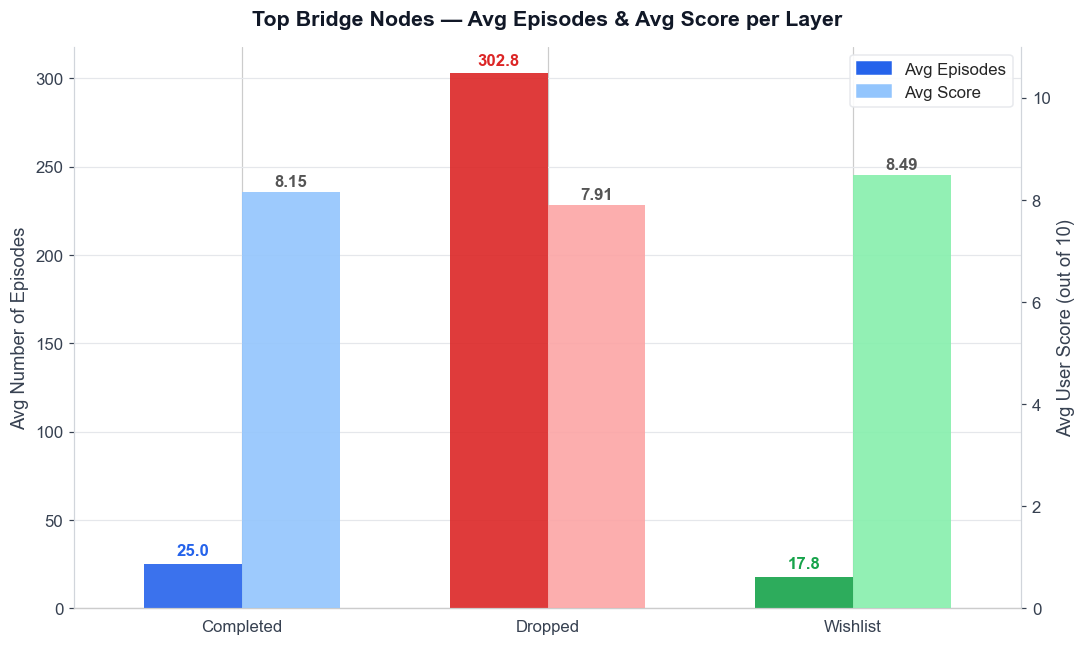

In [23]:
# Bar chart — avg episodes & avg score of top bridge nodes per layer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_layer_labels = []
_avg_eps      = []
_avg_scores   = []

for _name in layer_names:
    _items = _bridge_results.get(_name, [])
    _eps   = [_ep for _, _, _, _ep, _sc in _items if _ep is not None]
    _scs   = [_sc for _, _, _, _ep, _sc in _items if _sc is not None]
    _layer_labels.append(_name)
    _avg_eps.append(np.mean(_eps) if _eps else 0)
    _avg_scores.append(np.mean(_scs) if _scs else 0)

# colors
_DARK  = ["#2563EB", "#DC2626", "#16A34A"]
_LIGHT = ["#93C5FD", "#FCA5A5", "#86EFAC"]

_x, _w = np.arange(len(_layer_labels)), 0.32

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

ax2 = ax1.twinx()

# ✅ KEY FIXES
ax1.set_axisbelow(True)   # grid goes below everything
ax2.set_axisbelow(True)

ax2.grid(False)           # only ONE grid (from ax1)

# draw grid FIRST (low zorder)
ax1.grid(axis="y", color="#e5e7eb", linewidth=0.8, linestyle="-", zorder=0)

# bars (higher zorder so always above grid)
for _i, (_lbl, _ep, _sc) in enumerate(zip(_layer_labels, _avg_eps, _avg_scores)):
    ax1.bar(_i - _w/2, _ep, _w,
            color=_DARK[_i], alpha=0.9,
            edgecolor="none", zorder=3)

    ax2.bar(_i + _w/2, _sc, _w,
            color=_LIGHT[_i], alpha=0.9,
            edgecolor="none", zorder=3)

    # labels
    ax1.text(_i - _w/2, _ep + max(_avg_eps)*0.01, f"{_ep:.1f}",
             ha="center", va="bottom", fontsize=11,
             color=_DARK[_i], fontweight="bold", zorder=4)

    ax2.text(_i + _w/2, _sc + 0.05, f"{_sc:.2f}",
             ha="center", va="bottom", fontsize=11,
             color="#555555", fontweight="bold", zorder=4)

# axes
ax1.set_xticks(_x)
ax1.set_xticklabels(_layer_labels, fontsize=13)

ax1.set_ylabel("Avg Number of Episodes", fontsize=12, color="#374151")
ax2.set_ylabel("Avg User Score (out of 10)", fontsize=12, color="#374151")

ax2.set_ylim(0, 11)
ax1.set_xlim(-0.55, len(_layer_labels) - 0.45)
ax1.set_ylim(0)

# spines
for _spine in ["top", "right"]:
    ax1.spines[_spine].set_visible(False)
for _spine in ["top", "left"]:
    ax2.spines[_spine].set_visible(False)

ax1.spines["bottom"].set_color("#d1d5db")
ax1.spines["left"].set_color("#d1d5db")
ax2.spines["right"].set_color("#d1d5db")

ax1.tick_params(colors="#374151", labelsize=11)
ax2.tick_params(colors="#374151", labelsize=11)

# legend
_patches = [
    mpatches.Patch(color="#2563EB", label="Avg Episodes"),
    mpatches.Patch(color="#93C5FD", label="Avg Score"),
]

ax1.legend(handles=_patches, fontsize=11, loc="upper right",
           framealpha=0.9, edgecolor="#e5e7eb")

# title
ax1.set_title("Top Bridge Nodes — Avg Episodes & Avg Score per Layer",
              fontsize=14, fontweight="bold", color="#111827", pad=14)

plt.tight_layout()
plt.savefig("d2_bridge_episodes_score.png", dpi=160,
            bbox_inches="tight", facecolor="white")

plt.show()

### Inferences — Comparative Structural Analysis

---

#### 1. Structural Divergence (Modularity)

**Result:** Dropped (0.2290) is nearly **3× more modular** than Completed (0.0786).

**Inference:** The difference in modularity suggests meaningfully different structural organisation across layers. A score of ~0.08 for the **Completed** layer indicates *weak community structure* — the network is relatively cohesive, consistent with broadly consumed titles reducing the separation between groups. A score of ~0.23 for the **Dropped** layer indicates *moderate community structure* — the network partitions more cleanly into distinct subgroups, suggesting that abandonment behaviour is more type-specific than completion behaviour. This does not imply sharp, perfectly separated clusters; rather, it indicates that co-dropping patterns carry a stronger group signal than co-completing patterns.

---

#### 2. Bridge Node Structural Roles

**Completed Bridges:** *Shingeki no Kyojin* and *Death Note* have the highest betweenness centrality in the Completed layer. Structurally, this positions them as **widely consumed connectors** — titles that appear across many co-watching pairs and therefore link otherwise separate portions of the network. Whether this reflects quality, accessibility, or cultural exposure is not determinable from network structure alone.

**Dropped Bridges:** *Bleach* and *Naruto* are the highest-betweenness nodes in the Dropped layer. Structurally, these titles act as **cross-community connectors in abandonment behaviour** — they are co-dropped with anime from many different subgroups. This is consistent with their length and genre breadth, but the structural finding is that they sit between communities rather than within one; the social interpretation requires external validation.

**Wishlist Bridges:** *Mushishi* and *Shinsekai yori* occupy bridging positions in the Wishlist layer. Structurally, they appear in the wish-lists of users from otherwise distinct groups, making them **cross-community aspirational titles**. This pattern is consistent with, but does not confirm, the idea of "prestige" signalling — it may equally reflect algorithmic recommendation or shared demographic rather than aesthetic intent.

---

#### 3. Edge Set Jaccard Similarity — Context-Dependent Co-Behaviour

**Result:** All pairwise Jaccard values are very low (0.07 – 0.16).

**Inference:** The low overlap between edge sets is a **robust and well-supported finding**. It shows that the set of anime pairs that co-occur in one behavioural layer shares very little with those that co-occur in another. In practical terms, the relational structure of co-completion, co-dropping, and co-wishlisting are largely independent — knowing that two anime are frequently completed together tells you little about whether they are also frequently dropped together. This context-dependency is a substantive result that argues for treating each behavioural layer as a distinct network rather than a noisy version of the same underlying signal.

---

#### 4. Degree Distribution — Hub-Dominated Structure Across Layers

**Result:** All three layers show heavy-tailed degree distributions with log-log slopes between −0.53 and −0.58.

**Inference:** The similar slopes across layers indicate a **consistent hub-dominated structural tendency** — in each layer, a small number of anime accumulate disproportionately many co-behaviour connections while the majority have few. This pattern is *consistent with* scale-free behaviour, but should not be described as definitively power-law without formal statistical testing (e.g., maximum-likelihood fitting and goodness-of-fit tests as in Clauset et al., 2009). What the slopes do support is that the degree heterogeneity is structurally similar regardless of which behaviour is being measured, suggesting a common generative mechanism — likely the unequal popularity of titles across all consumption modes.


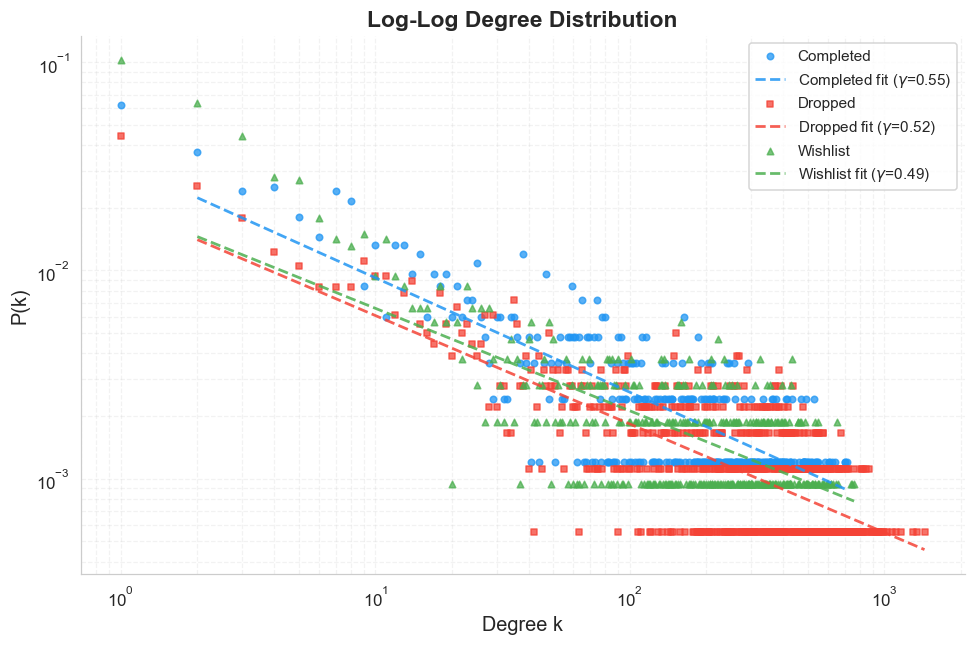

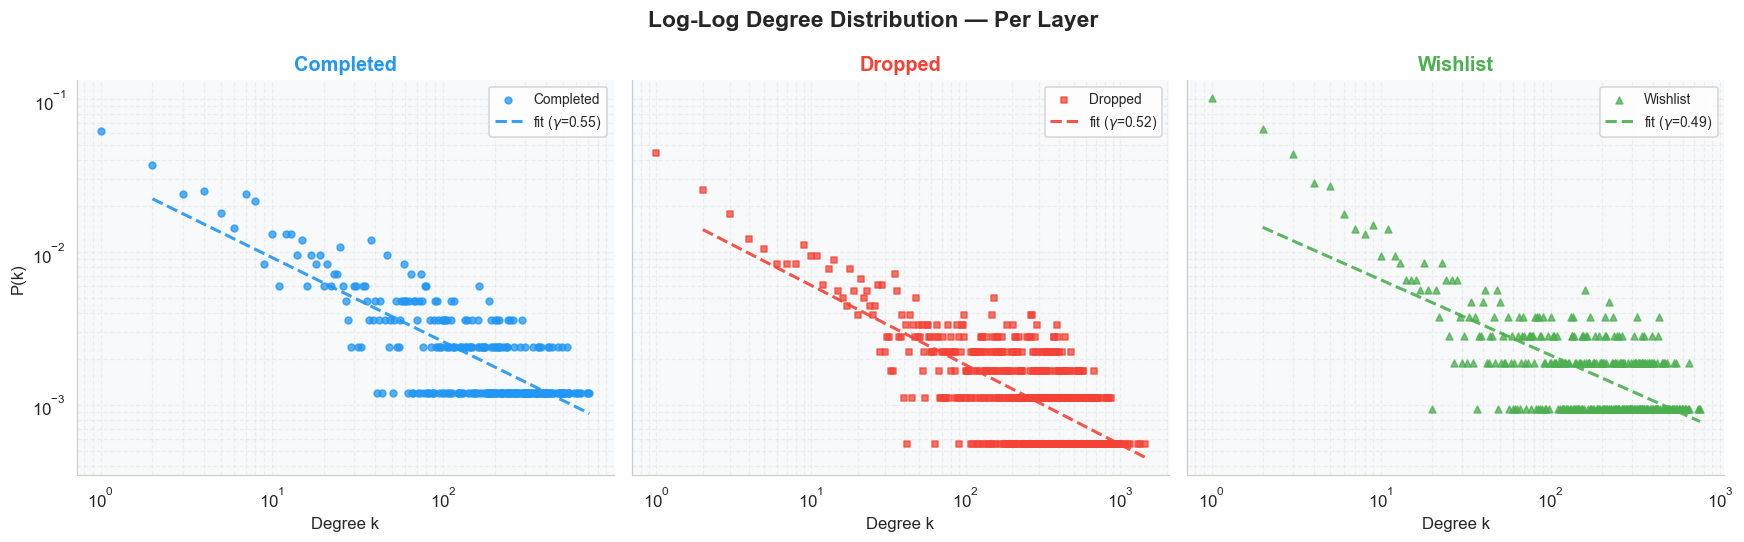

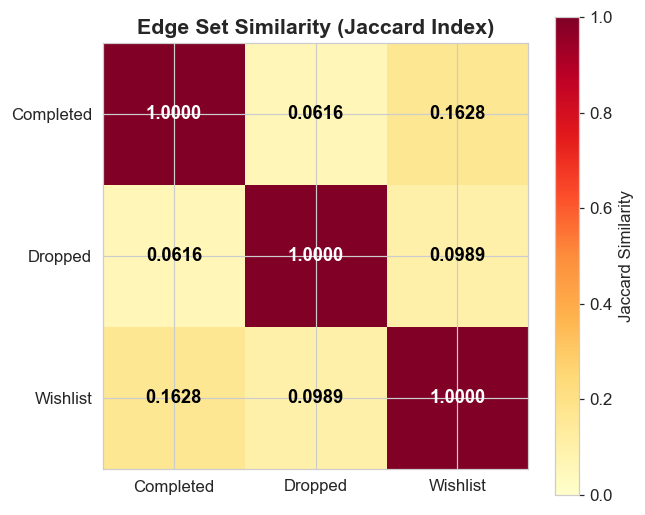

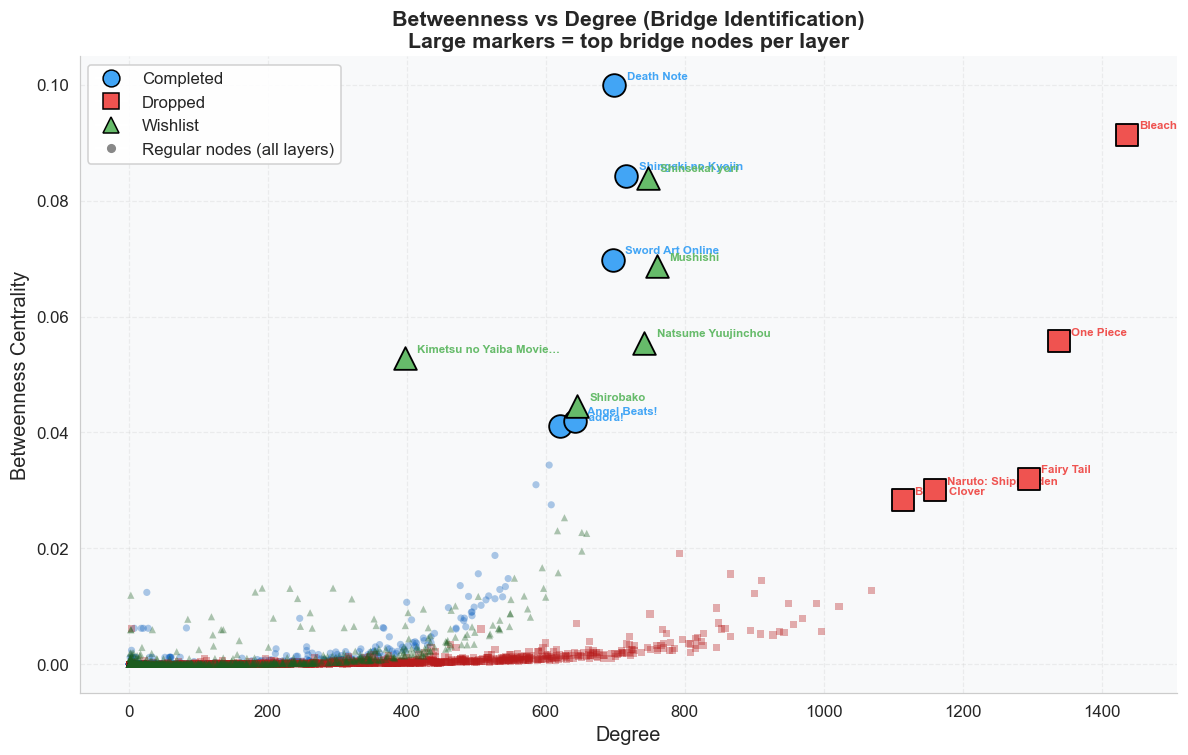

In [ ]:
# === Visualization Suite — Comparing Three Behavioral Layers ===
# Reuses: layer_names, layer_graphs, detect_communities_proj,
#         id_to_title, id_to_genres, RANDOM_SEED, j_cd, j_cw, j_dw

from collections import Counter
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

_LAYER_COLORS  = {"Completed": "#2196F3", "Dropped": "#F44336", "Wishlist": "#4CAF50"}
_LAYER_MARKERS = {"Completed": "o",       "Dropped": "s",        "Wishlist": "^"}



# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Plot 4  Log-Log Degree Distribution  P(k)
# Scatter only (no lines); fitted power-law per layer to validate scale-free claim
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for _name, _Gp in zip(layer_names, layer_graphs):
    _degs = [d for _, d in _Gp.degree() if d > 0]
    if not _degs:
        continue
    _counts = Counter(_degs)
    _total  = len(_degs)
    _ks     = np.array(sorted(_counts.keys()), dtype=float)
    _pk     = np.array([_counts[int(k)] / _total for k in _ks])

    # scatter points only — no connecting lines
    ax.scatter(_ks, _pk, color=_LAYER_COLORS[_name], marker=_LAYER_MARKERS[_name],
               s=18, alpha=0.75, label=_name)

    # fit power law in log-log space: log P(k) = -gamma * log k + c
    _mask = (_ks > 1) & (_pk > 0)
    if _mask.sum() > 3:
        _slope, _intercept = np.polyfit(np.log(_ks[_mask]), np.log(_pk[_mask]), 1)
        _k_fit  = np.logspace(np.log10(_ks[_mask].min()), np.log10(_ks[_mask].max()), 120)
        _pk_fit = np.exp(_intercept) * _k_fit ** _slope
        ax.plot(_k_fit, _pk_fit, "--", color=_LAYER_COLORS[_name],
                linewidth=1.8, alpha=0.85,
                label=fr"{_name} fit ($\gamma$={-_slope:.2f})")

ax.set_xlabel("Degree k", fontsize=13)
ax.set_ylabel("P(k)", fontsize=13)
ax.set_title("Log-Log Degree Distribution", fontsize=15, fontweight="bold")
ax.set_xscale("log"); ax.set_yscale("log")
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("vis_loglog_pk.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Plot 4b  Log-Log Degree Distribution — one subplot per layer, side by side
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Log-Log Degree Distribution — Per Layer", fontsize=15, fontweight="bold")

for ax, _name, _Gp in zip(axes, layer_names, layer_graphs):
    ax.set_facecolor("#F8F9FA")
    ax.grid(True, which="both", alpha=0.25, linestyle="--")

    _degs = [d for _, d in _Gp.degree() if d > 0]
    if not _degs:
        ax.set_title(_name, fontsize=13); continue

    _counts = Counter(_degs)
    _total  = len(_degs)
    _ks     = np.array(sorted(_counts.keys()), dtype=float)
    _pk     = np.array([_counts[int(k)] / _total for k in _ks])

    ax.scatter(_ks, _pk, color=_LAYER_COLORS[_name], marker=_LAYER_MARKERS[_name],
               s=20, alpha=0.75, label=_name)

    _mask = (_ks > 1) & (_pk > 0)
    if _mask.sum() > 3:
        _slope, _intercept = np.polyfit(np.log(_ks[_mask]), np.log(_pk[_mask]), 1)
        _k_fit  = np.logspace(np.log10(_ks[_mask].min()), np.log10(_ks[_mask].max()), 120)
        _pk_fit = np.exp(_intercept) * _k_fit ** _slope
        ax.plot(_k_fit, _pk_fit, "--", color=_LAYER_COLORS[_name],
                linewidth=2.0, alpha=0.9,
                label=fr"fit ($\gamma$={-_slope:.2f})")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Degree k", fontsize=11)
    ax.set_title(_name, fontsize=13, fontweight="bold",
                 color=_LAYER_COLORS[_name])
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

axes[0].set_ylabel("P(k)", fontsize=11)
plt.tight_layout()
plt.savefig("vis_loglog_pk_per_layer.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Plot 6  Edge Set Jaccard Similarity Heatmap  (matplotlib only, no seaborn)
# ─────────────────────────────────────────────────────────────────────────────
# compute Jaccard values inline (in case earlier cell variables are not in scope)
_def_edge_set = lambda G: {(min(u,v), max(u,v)) for u, v in G.edges()}
_def_jacc = lambda A, B: len(A & B) / len(A | B) if (A | B) else 0.0
_es = [_def_edge_set(Gp) for Gp in layer_graphs]
j_cd = _def_jacc(_es[0], _es[1])
j_cw = _def_jacc(_es[0], _es[2])
j_dw = _def_jacc(_es[1], _es[2])

_sim = np.array([
    [1.0,  j_cd, j_cw],
    [j_cd, 1.0,  j_dw],
    [j_cw, j_dw, 1.0 ],
])
fig, ax = plt.subplots(figsize=(6, 5))
_im = ax.imshow(_sim, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(_im, ax=ax, label="Jaccard Similarity")
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(layer_names, fontsize=11)
ax.set_yticklabels(layer_names, fontsize=11)
for _i in range(3):
    for _j in range(3):
        ax.text(_j, _i, f"{_sim[_i, _j]:.4f}",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if _sim[_i, _j] > 0.5 else "black")
ax.set_title("Edge Set Similarity (Jaccard Index)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("vis_jaccard_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Plot 7  Betweenness vs Degree Scatter Plot  (bridge nodes highlighted)
# ─────────────────────────────────────────────────────────────────────────────
_STRONG_COLORS  = {"Completed": "#1565C0", "Dropped": "#B71C1C", "Wishlist": "#1B5E20"}
_HIGHLIGHT_COLS = {"Completed": "#42A5F5", "Dropped": "#EF5350", "Wishlist": "#66BB6A"}
_TOP_BRIDGES    = 5   # annotate this many top-betweenness nodes per layer

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("white")
ax.grid(True, which="both", alpha=0.3, linestyle="--", color="#CCCCCC")

for _name, _Gp in zip(layer_names, layer_graphs):
    if _Gp.number_of_nodes() == 0:
        continue
    _gcc_n = max(nx.connected_components(_Gp), key=len)
    _Gg    = _Gp.subgraph(_gcc_n).copy()
    _btw   = nx.betweenness_centrality(
        _Gg, k=min(200, _Gg.number_of_nodes()), normalized=True, seed=RANDOM_SEED
    )
    _deg = dict(_Gg.degree())

    # split nodes into regular and top-bridge
    _sorted_by_btw = sorted(_btw.items(), key=lambda x: -x[1])
    _bridge_nodes  = {n for n, _ in _sorted_by_btw[:_TOP_BRIDGES]}
    _regular_nodes = [n for n in _Gg.nodes() if n not in _bridge_nodes]

    # regular nodes — small, semi-transparent, dark color
    ax.scatter(
        [_deg[n] for n in _regular_nodes],
        [_btw[n] for n in _regular_nodes],
        color=_STRONG_COLORS[_name], marker=_LAYER_MARKERS[_name],
        alpha=0.35, s=22, edgecolors="none",
    )

    # bridge nodes — large, fully opaque, bright highlight color, black border
    _bx = [_deg[n] for n in _bridge_nodes]
    _by = [_btw[n] for n in _bridge_nodes]
    ax.scatter(
        _bx, _by,
        color=_HIGHLIGHT_COLS[_name], marker=_LAYER_MARKERS[_name],
        s=220, alpha=1.0, edgecolors="black", linewidths=1.2,
        label=_name, zorder=5,
    )

    # annotate bridge nodes with anime title
    for _n in _bridge_nodes:
        _title = id_to_title.get(_n, str(_n))
        _title = _title[:22] + "…" if len(_title) > 22 else _title
        ax.annotate(
            _title,
            xy=(_deg[_n], _btw[_n]),
            xytext=(8, 4), textcoords="offset points",
            fontsize=7.5, color=_HIGHLIGHT_COLS[_name],
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=_HIGHLIGHT_COLS[_name],
                            lw=0.7, alpha=0.7),
        )

# build clean legend: one entry per layer (using the highlight scatter)
_leg_handles = [
    plt.Line2D([0],[0], marker=_LAYER_MARKERS[n], color="w",
               markerfacecolor=_HIGHLIGHT_COLS[n], markeredgecolor="black",
               markersize=11, label=n)
    for n in layer_names
]
_leg_handles.append(
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor="#888888", markersize=7,
               label="Regular nodes (all layers)")
)
ax.legend(handles=_leg_handles, fontsize=11, loc="upper left",
          framealpha=0.9, edgecolor="#CCCCCC")

ax.set_xlabel("Degree", fontsize=13)
ax.set_ylabel("Betweenness Centrality", fontsize=13)
ax.set_title("Betweenness vs Degree (Bridge Identification)\nLarge markers = top bridge nodes per layer",
             fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("vis_btw_vs_degree.png", dpi=150, bbox_inches="tight")
plt.show()